In [1]:
import pandas as pd
df=pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [17]:
y=df['loan_status']
x=df.drop(columns=['loan_status'])

In [18]:
from scipy import stats
feat=[]
sk,kt=0,0
for i in x.select_dtypes(include='number').columns:
    sk=abs(x[i].skew())
    kt=abs(x[i].kurt())
    reg,pval=0,0
    if sk<=1 and kt<=1:
        reg,pval=stats.pearsonr(x[i],y)
    else:
        reg,pval=stats.spearmanr(x[i],y)
    if pval<0.05:
        feat.append(i)
    

In [19]:
print(x.select_dtypes(include='object').columns)
print(x.select_dtypes(include='object'))

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')
      person_home_ownership      loan_intent loan_grade  \
0                      RENT         PERSONAL          D   
1                       OWN        EDUCATION          B   
2                  MORTGAGE          MEDICAL          C   
3                      RENT          MEDICAL          C   
4                      RENT          MEDICAL          C   
...                     ...              ...        ...   
32576              MORTGAGE         PERSONAL          C   
32577              MORTGAGE         PERSONAL          A   
32578                  RENT  HOMEIMPROVEMENT          B   
32579              MORTGAGE         PERSONAL          B   
32580                  RENT          MEDICAL          B   

      cb_person_default_on_file  
0                             Y  
1                             N  
2                             N  
3                             N  
4

In [23]:
print(feat)

['person_age', 'person_income', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [21]:
for i in x.select_dtypes(include='object').columns:
    gp=[grp['loan_status'].values for name,grp in df.groupby(i)]
    fstat,pval=0,0
    if(x[i].nunique()<=2):
        fstat,pval=stats.ttest_ind(*gp)
    else:
        fstat,pval=stats.f_oneway(*gp)
    if pval<=0.05:
        feat.append(i)

In [22]:
feat

['person_age',
 'person_income',
 'loan_amnt',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [38]:
print(x_train.isnull().sum())
print(x_test.isnull().sum())
print(y_train.isnull().sum())
print(y_test.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              702
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2530
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             193
loan_intent                     0
loan_grade                      0
loan_amnt                       0
loan_int_rate                 586
loan_percent_income             0
cb_person_default_on_file       0
cb_person_cred_hist_length      0
dtype: int64
0
0


In [39]:
x_train['loan_int_rate'].value_counts()

loan_int_rate
10.99    598
7.51     595
7.49     518
7.88     507
5.42     490
        ... 
14.70      1
20.53      1
16.08      1
19.39      1
20.52      1
Name: count, Length: 337, dtype: int64

In [40]:
median_rate=x_train['loan_int_rate'].median()
x_train.fillna({'loan_int_rate':median_rate},inplace=True)
x_test.fillna({'loan_int_rate':median_rate},inplace=True)

In [41]:
x_train['person_emp_length'].value_counts()

person_emp_length
0.0      3270
2.0      3063
3.0      2747
5.0      2344
1.0      2342
4.0      2284
6.0      2131
7.0      1791
8.0      1370
9.0      1104
11.0      612
10.0      551
12.0      451
13.0      340
14.0      276
15.0      191
16.0      134
17.0       98
18.0       84
19.0       51
20.0       36
21.0       34
22.0       16
23.0        9
25.0        7
24.0        6
26.0        6
27.0        3
31.0        3
30.0        2
123.0       2
28.0        1
29.0        1
34.0        1
41.0        1
Name: count, dtype: int64

In [42]:
med=x_train['person_emp_length'].median()
x_train.fillna({'person_emp_length':med},inplace=True)
x_test.fillna({'person_emp_length':med},inplace=True)

In [43]:
num=x_train.select_dtypes(include='number').columns
means=x_train[num].mean()
sc=StandardScaler()
x_train[num]=x_train[num].fillna(means)
x_test[num]=x_test[num].fillna(means)

In [44]:
encoders={}
for i in x_train.select_dtypes(include='object').columns:
    le=LabelEncoder()
    x_train[i]=le.fit_transform(x_train[i])
    x_test[i]=le.transform(x_test[i])
    encoders[i]=le

In [50]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
for k in range(3,37):
    knn=KNeighborsClassifier(n_neighbors=k,metric='minkowski')
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    print(k,round(accuracy_score(y_test,y_pred),3))

3 0.83
4 0.842
5 0.835
6 0.845
7 0.84
8 0.843
9 0.844
10 0.846
11 0.847
12 0.847
13 0.845
14 0.846
15 0.846
16 0.847
17 0.847
18 0.846
19 0.847
20 0.847
21 0.846
22 0.848
23 0.848
24 0.847
25 0.848
26 0.847
27 0.847
28 0.846
29 0.844
30 0.844
31 0.845
32 0.847
33 0.848
34 0.849
35 0.849
36 0.848


In [51]:
knn=KNeighborsClassifier(n_neighbors=25,metric='minkowski')
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)

accuracy:  0.8479361669479822


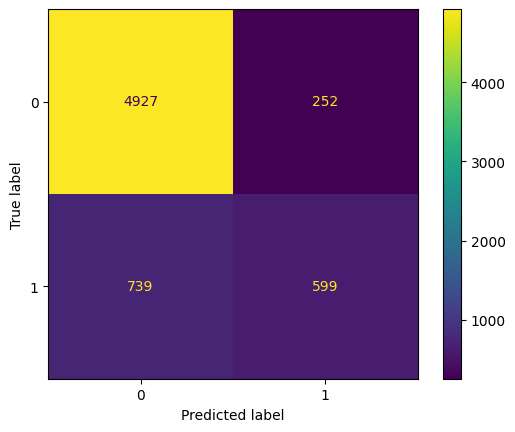

In [52]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
print("accuracy: ",accuracy_score(y_test,y_pred))
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()